# Deconvolution and spectral indices
We assume that you have created the hdf5 file of calibrated data and the mask defining the sediment.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import h5py

import spectral
from spectral import remove_continuum

from hyperspec.calib.bil_reader import BilReader
from hyperspec.file_finder import FileFinder
from hyperspec.util import scale_image

## get the hdf file and mask
We use the mask and hdf file from the previous notebook

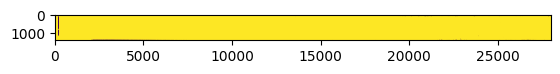

In [2]:
# try:
#     from _local import path_file_hdf5_iceland, path_file_mask_foreground_iceland, path_folder_iceland
#     path_file_hdf5 = path_file_hdf5_iceland
#     path_mask = path_file_mask_foreground_iceland
#     path_folder_capture = path_folder_iceland
# except:  # specify your files here
#     path_file_hdf5 = ...
#     path_mask = ...
#     path_folder_capture = ...

path_folder_capture = r"C:\Users\Yannick Zander\Downloads\WBA_23_WBA_23_2-A_2024-06-04_15-53-39\WBA_23_WBA_23_2-A_2024-06-04_15-53-39\capture"
path_file_hdf5 = r'C:\Users\Yannick Zander\Downloads\WBA_23_WBA_23_2-A_2024-06-04_15-53-39\WBA_23_WBA_23_2-A_2024-06-04_15-53-39\file.hdf5'
path_mask = r'C:\Users\Yannick Zander\Downloads\WBA_23_WBA_23_2-A_2024-06-04_15-53-39\WBA_23_WBA_23_2-A_2024-06-04_15-53-39\mask_foreground.npy'

mask_valid = np.load(path_mask)

plt.imshow(mask_valid.T)

In [3]:
ff = FileFinder(path_folder_capture)
bil_reader  = BilReader(
    path_file_header=ff.path_meas_header_file,
    path_file_binary=ff.path_meas_binary_file
)

## Sub-RoI definition
We define a 20 pixel wide section in the middle of the RoI to be used for spectral analysis.

In [4]:
hdf = h5py.File(path_file_hdf5, 'r')

dataset = hdf['roi_calibrated']

# place 20 pixel wide region for spectral processing at the center
width_roi = 20
row_start = 0
row_end = dataset.shape[0]
col_start = round(dataset.shape[1] / 2 - width_roi / 2)
col_end = col_start + width_roi
roi = dataset[row_start:row_end, col_start:col_end, :]
mask_valid_roi = mask_valid[row_start:row_end, col_start:col_end]

In [5]:
rgb_channels = [np.argmin(np.abs(wv - bil_reader.wavelengths_nm)) for wv in bil_reader.rgb_wavelengths]
rgb_img = np.stack([dataset[:, :, rgb_channel] for rgb_channel in rgb_channels], axis=-1)
rgb_roi = roi[:, :, rgb_channels]

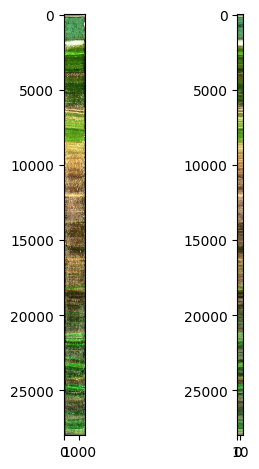

In [6]:
### plot imcube and ROI
fig, axs = plt.subplots(nrows=1, ncols=2, layout='tight')

axs[0].imshow(scale_image(rgb_img).astype(float))
axs[1].imshow(scale_image(rgb_roi).astype(float), aspect=1 / 20)

In [8]:
bands = bil_reader.wavelengths_nm

 # Spectral analysis on reduced data

mnf and PPI can be performed with `napari-sediment` as well but we lack some of the flexibility that we would like to have. Since it is based on the `spectral` library, we can make those calls here explicitly.

## MNF

In [8]:
print('calcing stats ...')
signal = spectral.calc_stats(roi, mask_valid_roi)
print('calcing noise ...')
noise = spectral.noise_from_diffs(roi)
print('calcing nmf ...')
mnfr = spectral.mnf(signal, noise)
print('done!')

calcing stats ...
calcing noise ...
calcing nmf ...
done!


In [9]:
signal.cov.shape

(476, 476)

plot some of the eigenvectors (in columns according to documentation)

creating plot ...


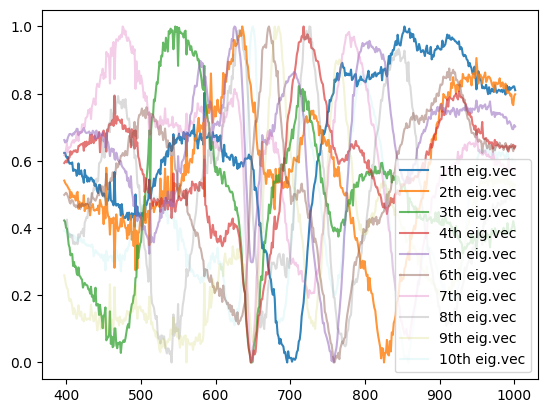

In [10]:
print('creating plot ...')
n_vecs = 10
plt.figure()
lams = bil_reader.wavelengths_nm
for i in range(n_vecs):
    v = mnfr.napc.eigenvectors[:, i].copy()
    v -= v.min()
    v /= v.max()
    plt.plot(lams, v, alpha=1 - (i + 1) / (n_vecs + 1), label=f'{i + 1}th eig.vec')
plt.legend()

plot eigenvalues

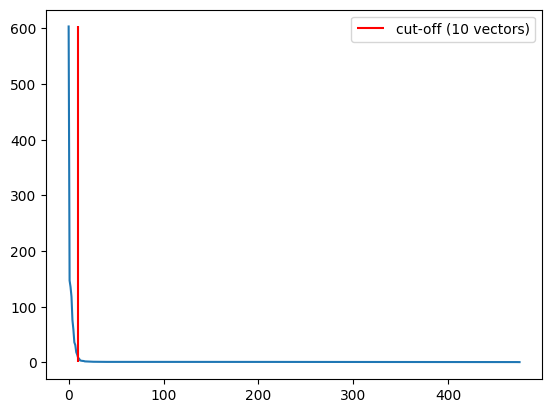

In [13]:
plt.plot(mnfr.napc.eigenvalues)
plt.vlines(n_vecs, 0, mnfr.napc.eigenvalues.max(), colors='red', label=f'cut-off ({n_vecs} vectors)')
plt.legend()

In [14]:
# De-noise the data by eliminating NAPC components where SNR < 10.
# The de-noised data will be in the original coordinate space (at
# full dimensionality).
print('denoising ...')
denoised_mnf = mnfr.denoise(roi, num=n_vecs)

denoising ...


### Reduce dimensionality, retaining top NAPC components.

In [15]:
reduced = mnfr.reduce(roi, num=n_vecs)

In [16]:
reduced.shape

(28000, 20, 10)

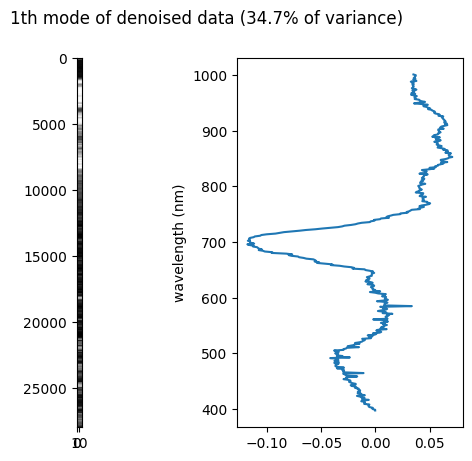

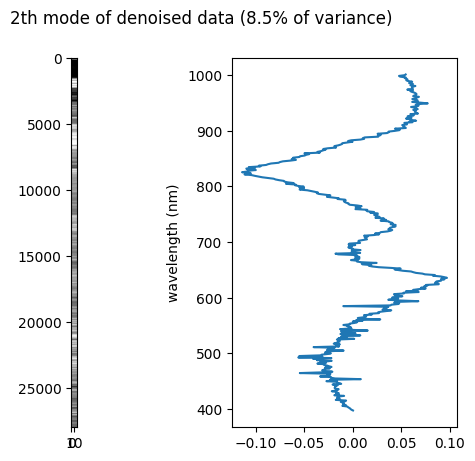

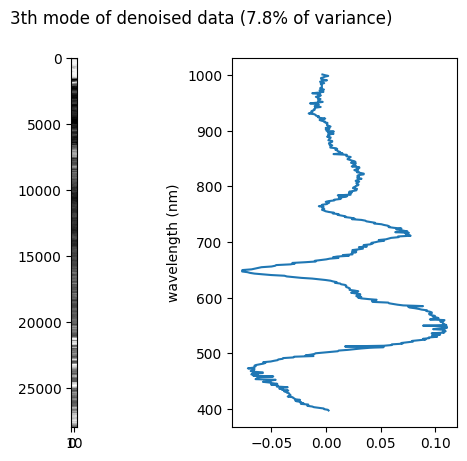

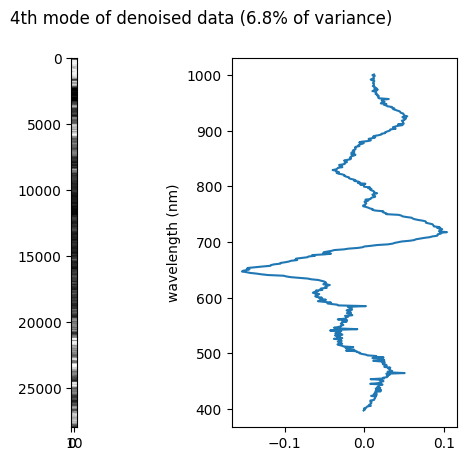

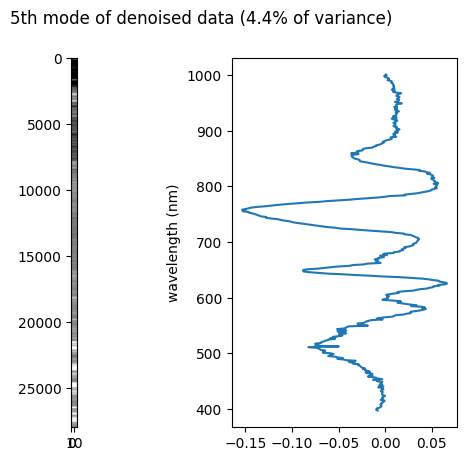

In [17]:
for i in range(min([n_vecs, 5])):
    fig, axs = plt.subplots(ncols=2)
    img = reduced[:, :, i]
    axs[0].imshow(img, vmin=np.quantile(img, .05), vmax=np.quantile(img, .95), aspect=1 / 20, cmap='grey')
    axs[1].plot(mnfr.napc.eigenvectors[:, i], lams)
    axs[1].set_ylabel('wavelength (nm)')
    fig.suptitle(
        f'{i + 1}th mode of denoised data ({mnfr.napc.eigenvalues[i] / mnfr.napc.eigenvalues.sum():.1%} of variance)')

## endmember idenfitication

### pixel purity index

Running 100 pixel purity iterations...done   


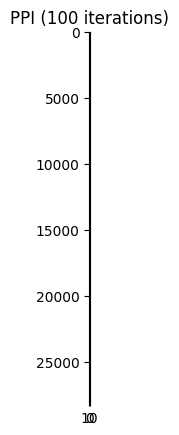

In [18]:
from scipy.signal import savgol_filter

n_iters_ppi = 100
counts = spectral.algorithms.ppi(reduced, niters=n_iters_ppi, centered=False, display=1)

In [19]:
# number of counts
thr_counts = n_iters_ppi / 30
mask_ppi = counts > thr_counts
endmembers = denoised_mnf[mask_ppi]
print(f'detected {endmembers.shape[0]} endmembers')

detected 7 endmembers


(np.uint32(0), np.uint32(21), np.float64(0.00035714285714285714))

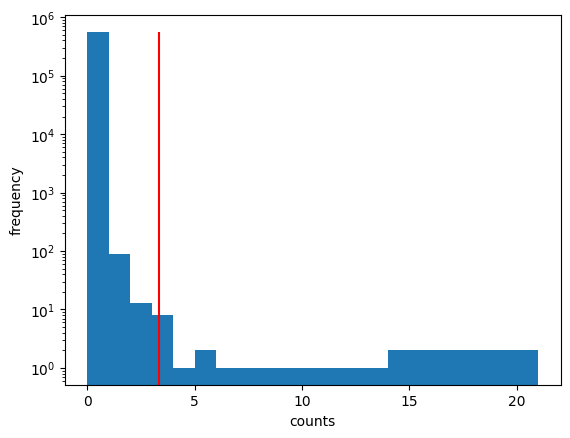

In [20]:
# how are counts distributed? ideally we have few pixels with high counts
ret = plt.hist(counts.ravel(), bins=np.unique(counts), log=True)
plt.vlines(thr_counts, 0, ret[0].max(), colors='red')
plt.xlabel('counts')
plt.ylabel('frequency')
counts.min(), counts.max(), counts.mean()

Text(0.5, 0, 'Wavelength (nm)')

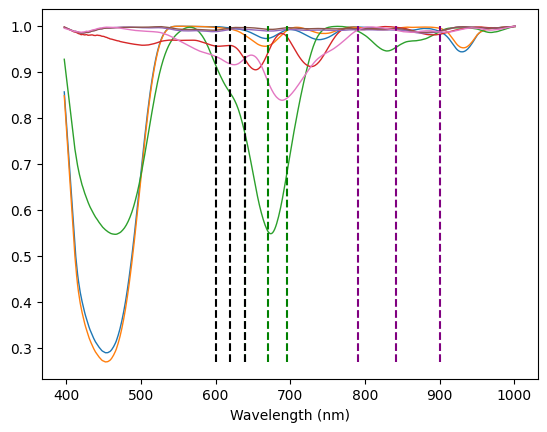

In [21]:
a = np.inf
b = -np.inf
for i in range(endmembers.shape[0]):
    y = remove_continuum(endmembers[i, :], bands=bands)
    y = savgol_filter(y, window_length=21, polyorder=1)
    if y.min() < a:
        a = y.min()
    if y.max() > b:
        b = y.max()
    plt.plot(bands, y, linewidth=1)
# Chl-a trough
plt.vlines([640, 670, 695], a, b, linestyles='--', colors='green')
#BChl-a trough
plt.vlines([790, 900, 842], a, b, linestyles='--', colors='purple')
# Phycocyanin trough
plt.vlines([620, 639, 600], a, b, linestyles='--', colors='black')
plt.xlabel('Wavelength (nm)')

### more robust pixel purity index

In [22]:
reduced.reshape(-1, reduced.shape[-1]).shape

(560000, 10)

In [24]:
from hyperspec.endmembers.fippi_from_github import FIPPI

endmembers, idcs = FIPPI(spectra=reduced.reshape(-1, reduced.shape[-1]))

In FIPPI, virtual dimensionality is: 0


IndexError: index 0 is out of bounds for axis 0 with size 0

In [25]:
endmembers = denoised_mnf.reshape(-1, denoised_mnf.shape[-1])[idcs, :]

plt.figure()
for i in range(endmembers.shape[0]):
    y = remove_continuum(endmembers[i, :], bands=bands)
    y_smooth = savgol_filter(y, window_length=21, polyorder=1)
    plt.plot(bands, y_smooth, c=f'C{i}')
    plt.plot(bands, y, linestyle='--', alpha=.5, c=f'C{i}')
plt.show()

NameError: name 'idcs' is not defined

### K-means

In [26]:
from sklearn.cluster import KMeans
import math

kmeans_on_denoised = True
kmeans_on_reduced = True
kmeans_on_normalized = False  # continuum contains information of total reflectance, which is useful information


def get_reduced_and_normalized(data):
    if kmeans_on_denoised:
        # assert not (kmeans_on_reduced or kmeans_on_normalized)
        data = mnfr.denoise(data, num=n_vecs)
    if kmeans_on_normalized:
        data = remove_continuum(data, bands=bands)
        # data = remove_avg_continuum(data)
        # data /= data.mean(axis=(0, 1))
    if kmeans_on_reduced:
        data = mnfr.reduce(data, num=n_vecs)
    return data


data_kmeans = get_reduced_and_normalized(roi)
data_kmeans[np.isnan(data_kmeans)] = 0
# reshape and mask
X_kmeans = data_kmeans[mask_valid_roi]

Text(0.5, 0, 'MNF dimension')

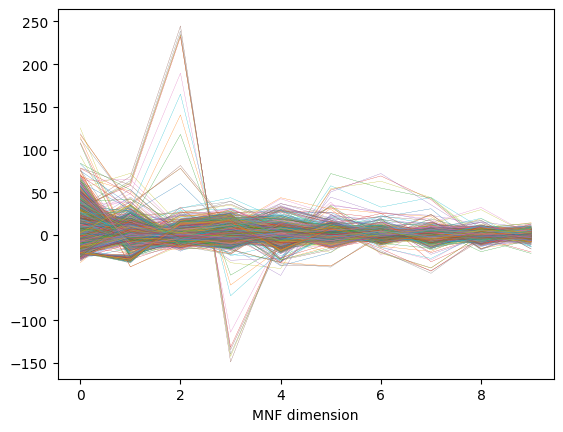

In [27]:
# make sure our X looks somewhat reasonable
n_test = 2000

for i in np.random.choice(range(X_kmeans.shape[0]), n_test, replace=False):
    plt.plot(X_kmeans[i, :], linewidth=.2)
plt.xlabel('MNF dimension')


#### find right number of clusters via silhoutte coefficient

In [28]:
from sklearn.metrics import silhouette_score

n_clusters_max = 10
clusters_to_test = np.arange(2, n_clusters_max + 1)

print('starting silhoutte calculation')
res = {}
for n_clusters in clusters_to_test:
    kmeans_sk = KMeans(n_clusters=n_clusters)
    cluster_labels = kmeans_sk.fit_predict(X_kmeans)
    silhouette_avg = silhouette_score(X_kmeans, cluster_labels, sample_size=1000)
    res[n_clusters] = (silhouette_avg, kmeans_sk)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

starting silhoutte calculation
For n_clusters = 2 The average silhouette_score is : 0.45497167020196955
For n_clusters = 3 The average silhouette_score is : 0.4234201765121662
For n_clusters = 4 The average silhouette_score is : 0.3726561617817192
For n_clusters = 5 The average silhouette_score is : 0.3947395293677524
For n_clusters = 6 The average silhouette_score is : 0.38985943256796984
For n_clusters = 7 The average silhouette_score is : 0.369442708800922
For n_clusters = 8 The average silhouette_score is : 0.30067081953373
For n_clusters = 9 The average silhouette_score is : 0.2971687813863633
For n_clusters = 10 The average silhouette_score is : 0.29464035097222147


In [29]:
# we want the highest silhoutte coefficient
idx = np.argmax([r[0] for r in res.values()])
# n_clusters_best = clusters_to_test[idx]
n_clusters_best = 4
kmeans_sk = res[n_clusters_best][1]
print(f'the highest scoring option is {n_clusters_best} clusters')

the highest scoring option is 4 clusters


In [30]:
# already fitted, so we can just predict (even the holes
labels = kmeans_sk.predict(data_kmeans.reshape(math.prod(reduced.shape[:2]), -1)).reshape(reduced.shape[:2])

In [31]:
# add new label for holes
# for ngist colormap it makes sense to set this label to the highest value since it appears as white
labels[~mask_valid_roi] = labels.max() + 1
u_labels = np.unique(labels)
n_labels = len(u_labels)

# use denoised (and normalized) to recalculate cluster centers
centers_kmeans = np.zeros((n_labels, roi.shape[2]))

if kmeans_on_normalized:
    for_centers = remove_continuum(roi, bands=bands)
else:
    for_centers = roi

for i, l in enumerate(u_labels):
    mask_label = labels == l
    centers_kmeans[i, :] = for_centers[mask_label, :].mean(axis=0)

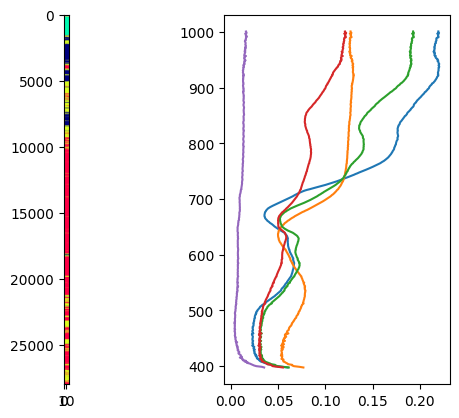

In [32]:
fig, axs = plt.subplots(ncols=2)
axs[0].imshow(labels, aspect=1 / 20, cmap='gist_ncar')
for i in range(centers_kmeans.shape[0]):
    axs[1].plot(centers_kmeans[i, :], bands)

#### extent kmeans annotations to entire image

In [33]:
print('this will take a while and a lot of memory ...')
print('converting to np array ...')
imcube_for_pred = np.asarray(dataset, dtype=float)
if kmeans_on_normalized:
    print('removing continuum ...')
    imcube_for_pred = remove_continuum(imcube_for_pred, bands=bands)
    if kmeans_on_reduced:
        print('reducing ...')
        imcube_for_pred = mnfr.reduce(imcube_for_pred, num=n_vecs)
elif kmeans_on_reduced:
    print('reducing ...')
    imcube_for_pred = mnfr.reduce(imcube_for_pred, num=n_vecs)
imcube_for_pred[np.isnan(imcube_for_pred)] = 0
print('Done!')

this will take a while and a lot of memory ...
converting to np array ...


MemoryError: Unable to allocate 139. GiB for an array with shape (28000, 1400, 476) and data type float64

make sure spectra in imcube look similar to those of the ROI used to fit K-Means

In [ ]:
n_test = 1000
random_indices = list(zip(
    np.random.choice(np.arange(imcube_for_pred.shape[0]), size=n_test),
    np.random.choice(np.arange(imcube_for_pred.shape[1]), size=n_test)
))

for i, j in random_indices:
    spec = imcube_for_pred[i, j, :]
    plt.plot(spec)

In [ ]:
from tqdm import tqdm

ncols, nrows = dataset.shape[:2]

I, J = np.meshgrid(range(ncols), range(nrows))
ij = zip(I.ravel(), J.ravel())

if not kmeans_on_reduced:
    print('only works for not reduced, would need some other method otherwise')

labels_full = np.zeros((ncols, nrows))

label_invalid = labels.max()
for i, j in tqdm(ij, total=ncols * nrows):
    if not mask_valid[i, j]:
        labels_full[i, j] = label_invalid
    else:
        labels_full[i, j] = kmeans_sk.predict(imcube_for_pred[i, j, :].reshape(1, -1))[0]

In [ ]:
np.unique(labels_full, return_counts=True)

In [ ]:
import matplotlib

remove_continuum_if_not_on_normalized = False

fig, axs = plt.subplots(ncols=4, sharey=False, layout='constrained', figsize=(6, 7))
axs[0].imshow(scale_image(rgb_img).astype(float))
axs[1].imshow(mask_valid)
axs[2].imshow(labels_full, cmap='gist_ncar')

cmap = matplotlib.colormaps['gist_ncar']
n_centers = centers_kmeans.shape[0]
for i in range(n_centers):
    y = centers_kmeans[i, :]
    if remove_continuum_if_not_on_normalized and (not kmeans_on_normalized):
        y = remove_continuum(y, bands=bands)
    axs[3].plot(y, bands, c=cmap(i / (n_centers - 1)))

# add bars for rgb channels
wl_rgb = bands[rgb_channels]
# axs[3].hlines(wl_rgb, 0, centers_kmeans.max, colors=['r', 'g', 'b'])

axs[3].set_ylabel('wavelength (nm)')
axs[3].set_title('')
fig.suptitle(f'K-Means clusters for {n_clusters_best} clusters ({kmeans_on_normalized=}, {kmeans_on_reduced=})')
# fig.savefig('clusters.pdf')

## Spectral indices

In [5]:
def get_img_for_wavelength(lam, array3D):
    idx = np.argmin(np.abs(bands - lam))

    return array3D[:, :, idx].astype(float)

def NDCI(array3D):
    """Normalized difference chlorophyll index"""
    R_705 = get_img_for_wavelength(705, array3D)
    R_665 = get_img_for_wavelength(670, array3D)
    return (R_705 - R_665) / (R_705 + R_665)

def RABD670(array3D):
    """Chl-a from https://bg.copernicus.org/articles/20/2221/2023/"""
    R_670 = get_img_for_wavelength(670, array3D)
    R_640 = get_img_for_wavelength(640, array3D)
    R_695 = get_img_for_wavelength(695, array3D)
    return ((19 * R_640 + 16 * R_695) / 35 / R_670)

def RABD842(array3D):
    """BChl-a from https://bg.copernicus.org/articles/20/2221/2023/"""
    R_790 = get_img_for_wavelength(790, array3D)
    R_900 = get_img_for_wavelength(900, array3D)
    R_842 = get_img_for_wavelength(695, array3D)
    return ((33 * R_790 + 36 * R_900) / 99 / R_842)

def RABD620(array3D):
    """phycocyanin"""
    center = 620
    left = 600
    right = 640
    R_center = get_img_for_wavelength(center, array3D)
    R_left = get_img_for_wavelength(left, array3D)
    R_right = get_img_for_wavelength(right, array3D)
    X_right = right - center
    X_left = center - left
    return ((X_right * R_left + X_left * R_right) / (X_right + X_left) / R_center)

def CI(array3D):
    """Cyanobacteria index"""
    R_560 = get_img_for_wavelength(560, array3D)
    R_665 = get_img_for_wavelength(665, array3D)
    R_705 = get_img_for_wavelength(705, array3D)
    return -((R_665 - R_560) - (R_705 - R_560) * (665 - 560) / (705 - 560))

def PHY(array3D):
    return get_img_for_wavelength(620, array3D)

In [29]:
def y_pixel_idx_to_depth(n_pixels_y, depth_interval: tuple):
    assert depth_interval[0] < depth_interval[1], 'depth interval must be increasing'
    def pixel_to_depth(pixel_idx):
        return depth_interval[0] + (depth_interval[1] - depth_interval[0]) * pixel_idx / n_pixels_y
    return pixel_to_depth

def get_index_1d(img, mask=True):
    img[~mask_valid] = np.nan
    if mask:
        mask_rows = (~np.isnan(img)).mean(axis=1) > .1
        return np.nanmean(img[mask_rows, :], axis=1)
    return np.nanmean(img, axis=1)

def plot_index(img, fig=None, axs=None, depth_interval=None):
    if axs is None:
        fig, axs = plt.subplots(ncols=2, sharey=True, layout='tight', figsize=(4, 8))

    img[~mask_valid] = np.nan

    mask_rows = (~np.isnan(img)).mean(axis=1) > .1
    axs[0].imshow(scale_image(img))
    axs[1].plot(get_index_1d(img), np.arange(phy.shape[0])[mask_rows], c='k', linewidth=.25)
    axs[1].set_xlabel('index')
    axs[0].set_ylabel('Depth (cm)')

    # scale x
    if depth_interval is not None:
        depth_func = y_pixel_idx_to_depth(img.shape[0], depth_interval)
        ticklabels: list[str] = axs[0].get_yticklabels()
        print(ticklabels)
        axs[0].set_yticklabels([round(depth_func(tlabel.get_position()[1]),1) for tlabel in ticklabels])

    return fig, axs

In [27]:
ndci = NDCI(dataset)
ndci[~mask_valid] = np.nan

chl_a = RABD670(dataset)
chl_a[~mask_valid] = np.nan

bchl_a = RABD842(dataset)
bchl_a[~mask_valid] = np.nan

ci = CI(dataset)
ci[~mask_valid] = np.nan

phy = RABD620(dataset)
phy[~mask_valid] = np.nan

C:\Users\Yannick Zander\AppData\Local\Temp\ipykernel_6800\3040761101.py:17: RuntimeWarning: divide by zero encountered in divide
  return ((19 * R_640 + 16 * R_695) / 35 / R_670)


KeyboardInterrupt: 

[Text(0, -5000.0, '−5000'), Text(0, 0.0, '0'), Text(0, 5000.0, '5000'), Text(0, 10000.0, '10000'), Text(0, 15000.0, '15000'), Text(0, 20000.0, '20000'), Text(0, 25000.0, '25000'), Text(0, 30000.0, '30000')]


C:\Users\Yannick Zander\AppData\Local\Temp\ipykernel_6800\1888555463.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([round(depth_func(tlabel.get_position()[1]),1) for tlabel in ticklabels])


Text(0.5, 0.98, 'Chl-a (NDCI)')

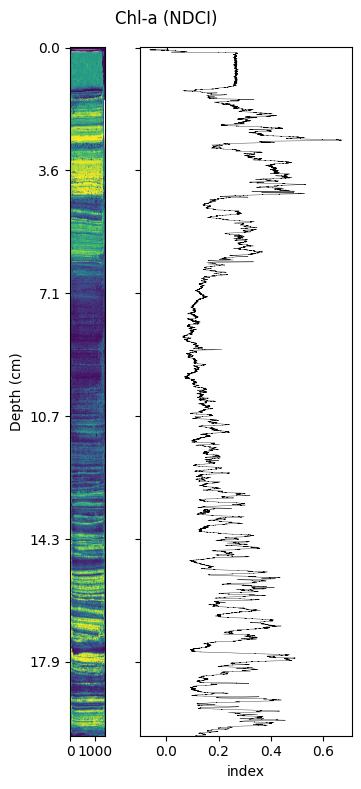

In [30]:
# scale
depth_interval = (0, 20)  # 0 to 20 cm
fig, axs = plot_index(ndci, depth_interval=depth_interval)
fig.suptitle('Chl-a (NDCI)')
# plt.savefig("NDCI.png", dpi=300)

[Text(0, -5000.0, '−5000'), Text(0, 0.0, '0'), Text(0, 5000.0, '5000'), Text(0, 10000.0, '10000'), Text(0, 15000.0, '15000'), Text(0, 20000.0, '20000'), Text(0, 25000.0, '25000'), Text(0, 30000.0, '30000')]


C:\Users\Yannick Zander\AppData\Local\Temp\ipykernel_6800\1888555463.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([round(depth_func(tlabel.get_position()[1]),1) for tlabel in ticklabels])


Text(0.5, 0.98, 'Chl-a (RABD 670)')

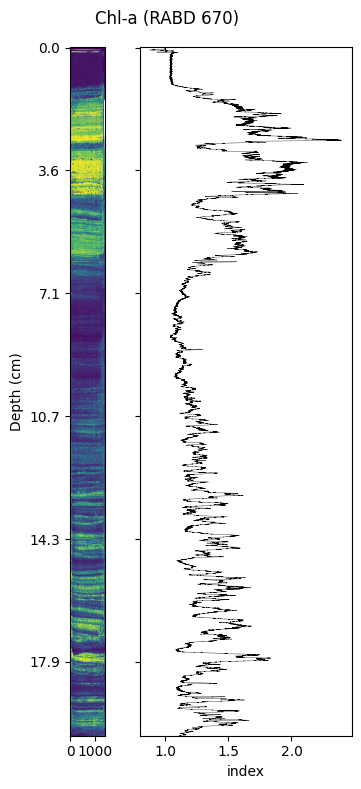

In [31]:
fig, axs = plot_index(chl_a, depth_interval=depth_interval)
fig.suptitle('Chl-a (RABD 670)')
# plt.savefig("RABD670.png", dpi=300)

[Text(0, -5000.0, '−5000'), Text(0, 0.0, '0'), Text(0, 5000.0, '5000'), Text(0, 10000.0, '10000'), Text(0, 15000.0, '15000'), Text(0, 20000.0, '20000'), Text(0, 25000.0, '25000'), Text(0, 30000.0, '30000')]


C:\Users\Yannick Zander\AppData\Local\Temp\ipykernel_6800\1888555463.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([round(depth_func(tlabel.get_position()[1]),1) for tlabel in ticklabels])


Text(0.5, 0.98, 'BChl-a (RABD 842)')

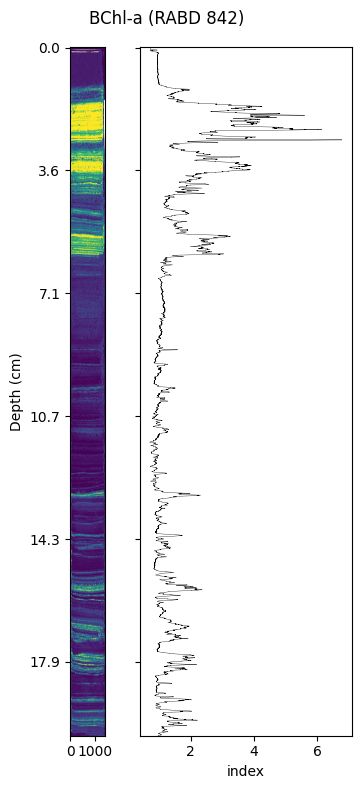

In [32]:
fig, axs = plot_index(bchl_a, depth_interval=depth_interval)
fig.suptitle('BChl-a (RABD 842)')
# plt.savefig("RABD842.png", dpi=300)

[Text(0, -5000.0, '−5000'), Text(0, 0.0, '0'), Text(0, 5000.0, '5000'), Text(0, 10000.0, '10000'), Text(0, 15000.0, '15000'), Text(0, 20000.0, '20000'), Text(0, 25000.0, '25000'), Text(0, 30000.0, '30000')]


C:\Users\Yannick Zander\AppData\Local\Temp\ipykernel_6800\1888555463.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([round(depth_func(tlabel.get_position()[1]),1) for tlabel in ticklabels])


Text(0.5, 0.98, 'Phycocyanin (RABD620)')

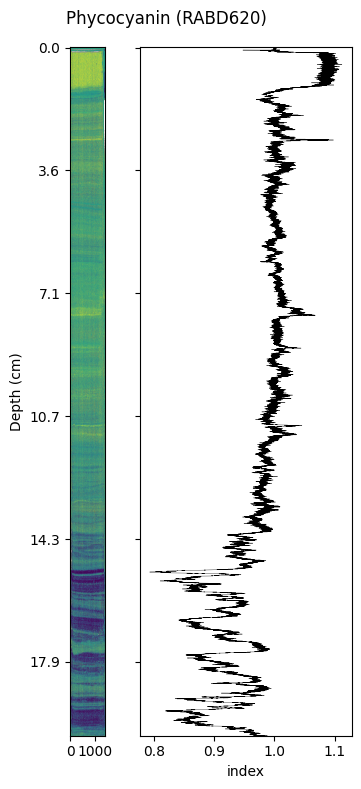

In [33]:
# scale
fig, axs = plot_index(phy, depth_interval=depth_interval)
fig.suptitle('Phycocyanin (RABD620)')
# plt.savefig("RABD620.png", dpi=300)

## Store result as csv


In [35]:
import pandas as pd

depth_func = y_pixel_idx_to_depth(ndci.shape[0], depth_interval)
df = pd.DataFrame({
    'depth': [depth_func(i) for i in range(ndci.shape[0])],
    'ndci': get_index_1d(ndci, mask=False),
    'chl-a': get_index_1d(chl_a, mask=False),
    'bchl-a': get_index_1d(bchl_a, mask=False),
    'phycocyanin': get_index_1d(phy, mask=False)
})

df.to_csv('temp.csv', index=False, sep=',')